In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
# These imports help with balancing the dataset.
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

In [3]:
df = pd.read_csv("./diabetes2.csv")

## Diabetes Data

From viewing the dataset all the columns have data that can be used with any change such as 1-hot encoding, cleaning, etc...

In [4]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


Here I am checking the imbalance in dataset to see how many more false cases we have compared to true cases. Since this dataset is skewed we will have to use F1-score to tell how accurate our model is at predicting. We cannot simply check model accuracy based on how many cases the model accurately classifies on the test dataset because even a poor model (ex: A model that always outputs false or 0) can produce decent results because majority of the test dataset contains false examples.

In [5]:
# Checking the ratio of true to false cases in the dataset.
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [6]:
y= df["Outcome"]
X = df[["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]]

In [7]:
print(X.shape)
print(y.shape)

(768, 8)
(768,)


In [8]:
# Splitting the dataset into train and test. The split is a 80:20 split.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# Initializing the logistic regression sciKit learn object.
lr_model = LogisticRegression(max_iter=2000)
# Calling fit() on the lr_model which will fit the train dataset using the processes I discussed in the article.
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

In [10]:
y_pred = lr_model.predict(X_test)

In [11]:
print("Accuracy on training set:", lr_model.score(X_test, y_test))

Accuracy on training set: 0.7467532467532467


### Analysing model with no changes to the data
The f1 score indicates that our model is doing quite poorly (a score of 1 indicates a perfect model). The confusion matrix tells us that the model is making a low number of True Positive predictions out of True positive and False positive predictions which means our model's precision is quite low.

In [12]:
f1_score(y_test, y_pred)

0.6548672566371682

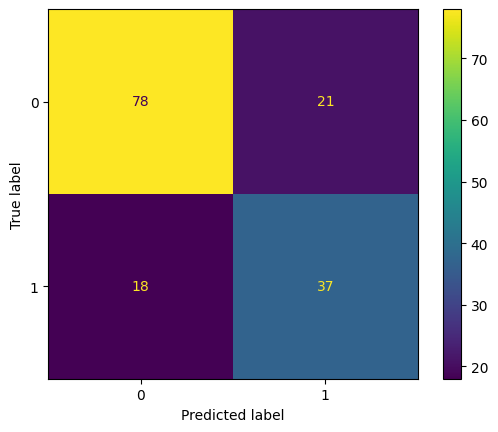

In [13]:
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot()

### Augmenting our data

We are going to use SMOTE (Synthetic Minority Oversampling Technique) which creates synthetic examples of our minority in our dataset (true cases). This technique is called oversampling. As you can see using SMOTE balanced our dataset and we have equal number of examples for both cases.

In [14]:
# Creating an oversampling, undersampling data pipeline
smote = SMOTE(sampling_strategy="minority")

X_sm, y_sm = smote.fit_resample(X, y)

In [15]:
# As you can now see SMOTE made equal number of true and false cases. Before we have 500 true cases and 268 false cases.
print(y_sm.value_counts())

Outcome
1    500
0    500
Name: count, dtype: int64


In [16]:
# Splitting the dataset into train and test. The split is a 80:20 split.
X_train, X_test, y_train, y_test = train_test_split(X_sm, y_sm, test_size=0.2, random_state=42, stratify=y_sm)

In [17]:
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

### Final analysis
We were able to significantly increase our model's F1-score by using oversampling with SMOTE. Our model now scores 0.74 on the F1-score and as much more True positive predictions. Although we'd like our model to have a score closer to 0.9-1, this limitation is most likely a result of our dataset's size. I will be discussing how to handling skewed datasets in the future in an article so if you did not understand what F1-score, precision, and oversampling it is completely fine.

In [18]:
y_pred = lr_model.predict(X_test)

In [19]:
f1_score(y_test, y_pred)

0.746268656716418

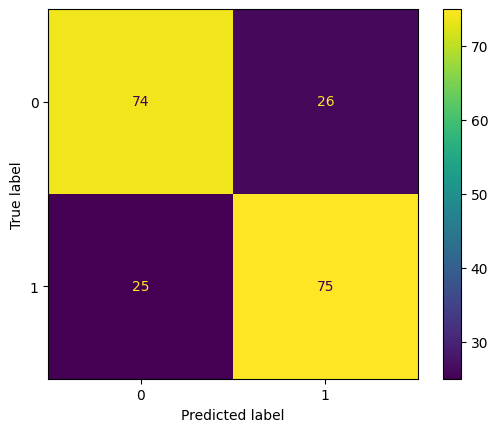

In [20]:
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot()